<a href="https://colab.research.google.com/github/Hansen256/NLP_coursework_1/blob/main/group1_hybrid_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 1: Social Media Text Preprocessing (Hybrid NLP)

This notebook implements the coursework tasks for:
- **Dataset A (English):** Sentiment140 Twitter Dataset
- **Dataset B (African language):** Swahili News Classification Dataset

Three preprocessing pipelines are applied to each dataset:
1. **Rule-based** — regex cleaning (URLs, mentions, emojis, punctuation, lowercasing, number filtering)
2. **Statistical** — TF-IDF and entropy-based stop-word filtering
3. **Deep learning** — spaCy NER-aware lemmatization (English), multilingual transformer normalization (Swahili)

Each pipeline is evaluated for its effectiveness in supporting topic discovery.

## 0) Installation
Run once to install all required packages. No kernel restart needed — spaCy model is downloaded here and verified at import time.

In [3]:
# All dependencies in one cell — keeps requirements.txt and this install in sync.
# spaCy model downloaded here rather than at import time to avoid silent failures.
!pip install kagglehub gensim sentence-transformers transformers scikit-learn -q
!pip install matplotlib seaborn sentencepiece -q
!pip install "spacy>=3.7,<3.9" -q
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 123.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1) Imports & Configuration
Central config dict — change values here to affect the entire notebook.

In [4]:
# ── Standard library ─────────────────────────────────────────────────────────
import os
import re
import sys
import glob
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import kagglehub

# ── ML / NLP ──────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

import spacy
from transformers import AutoTokenizer, pipeline as hf_pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Configuration ─────────────────────────────────────────────────────────────
# Single dict controls all tunable parameters across the notebook.
CFG = {
    'seed': 42,
    'sample_size': 50_000,
    'lda_topics': 8,
    'lda_seeds': [42, 43, 44, 45, 46],   # 5 seeds for stability estimation
    'spacy_batch': 256,
    'ner_batch': 32,
    'stat_entropy_pct': 90,               # percentile threshold for entropy stopwords
    'stat_min_df': 5,                     # minimum document frequency for entropy calc
    'meaning_sample': 1000,               # rows sampled for meaning preservation
    'mattr_window': 100,                  # window size for MATTR
}

# ── Reproducibility seeds ────────────────────────────────────────────────────
# torch.manual_seed included because transformer pipelines use PyTorch backends.
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])

print('Configuration loaded.')
print('GPU available:', torch.cuda.is_available())

Configuration loaded.
GPU available: True


## 2) Environment & Paths
Auto-detects Colab vs local and sets output directories accordingly.

In [5]:
# Detect runtime once here — all subsequent cells read IS_COLAB, never re-detect.
IS_COLAB = 'google.colab' in sys.modules

# pathlib throughout: avoids os.path.join chains and handles cross-OS separators.
if IS_COLAB:
    ROOT = Path('/content')
else:
    # Works whether Jupyter is launched from repo root or the notebooks/ directory.
    _cwd = Path.cwd()
    ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd

RAW_DIR       = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
REPORTS_DIR   = ROOT / 'reports'
FIGURES_DIR   = REPORTS_DIR / 'figures'

# Google Drive persistence (Colab only) — files survive runtime resets.
if IS_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        _drive_root = Path('/content/drive/MyDrive/nlp_coursework_1')
        PROCESSED_DIR = _drive_root / 'data' / 'processed'
        REPORTS_DIR   = _drive_root / 'reports'
        FIGURES_DIR   = _drive_root / 'reports' / 'figures'
        print('Outputs redirected to Google Drive:', _drive_root)
    except Exception as e:
        print(f'Google Drive mount skipped ({e}). Falling back to local paths.')

for d in [RAW_DIR, PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('PROCESSED_DIR:', PROCESSED_DIR)

Mounted at /content/drive
Outputs redirected to Google Drive: /content/drive/MyDrive/nlp_coursework_1
ROOT: /content
PROCESSED_DIR: /content/drive/MyDrive/nlp_coursework_1/data/processed


## 3) Kaggle Credentials
Upload `kaggle.json` if running on Colab and credentials are not already present.

In [6]:
# google.colab.files only exists on Colab — guard prevents ImportError locally.
_kaggle_path = Path.home() / '.kaggle' / 'kaggle.json'

if IS_COLAB and not _kaggle_path.exists():
    from google.colab import files
    print('Please upload your kaggle.json file:')
    uploaded = files.upload()
    _kaggle_path.parent.mkdir(parents=True, exist_ok=True)
    Path('kaggle.json').rename(_kaggle_path)
    _kaggle_path.chmod(0o600)
    print('Kaggle credentials configured.')
else:
    print('Kaggle credentials already present (or running locally).')

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


## 4) Data Loading
Downloads both datasets via kagglehub, loads into DataFrames, deduplicates, normalizes labels, and takes a stratified sample.

In [7]:
# ── Download datasets ─────────────────────────────────────────────────────────
# Dataset versions noted — re-pin if kagglehub returns a newer version unexpectedly.
# kazanova/sentiment140 — 1.6M tweets, labels 0=negative / 4=positive
# waalbannyantudre/swahili-news-classification-dataset — news articles, NOT tweets
_en_dir = kagglehub.dataset_download('kazanova/sentiment140')
_sw_dir = kagglehub.dataset_download('waalbannyantudre/swahili-news-classification-dataset')


def find_csv(directory, preferred_name=None):
    """Return path to a CSV inside `directory`, preferring `preferred_name`."""
    if preferred_name:
        candidate = os.path.join(directory, preferred_name)
        if os.path.exists(candidate):
            return candidate
    matches = glob.glob(os.path.join(directory, '**', '*.csv'), recursive=True)
    if not matches:
        raise FileNotFoundError(f'No CSV files found in {directory}')
    return sorted(matches)[0]


CSV_PATHS = {
    'english': find_csv(_en_dir, 'training.1600000.processed.noemoticon.csv'),
    'swahili': find_csv(_sw_dir, 'train.csv'),
}

for name, path in CSV_PATHS.items():
    print(f'{name} -> {path}  (exists: {os.path.exists(path)})')

Using Colab cache for faster access to the 'sentiment140' dataset.


100%|██████████| 18.1M/18.1M [00:01<00:00, 9.99MB/s]

Extracting files...


english -> /kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv  (exists: True)
swahili -> /root/.cache/kagglehub/datasets/waalbannyantudre/swahili-news-classification-dataset/versions/1/SwahiliNewsClassificationDataset.csv  (exists: True)


In [8]:
# ── Load English (Sentiment140) ──────────────────────────────────────────────
# Standard layout: 6 columns, no header row, ISO-8859-1 encoding.
_en_raw = pd.read_csv(
    CSV_PATHS['english'], encoding='ISO-8859-1', header=None,
    names=['sentiment', 'tweet_id', 'date', 'query', 'user', 'text'],
    usecols=['sentiment', 'text'],
)

# Normalize labels 0/4 -> 0/1 so outputs are classifier-ready.
_en_raw['sentiment'] = _en_raw['sentiment'].map({0: 0, 4: 1})

# ── Load Swahili ─────────────────────────────────────────────────────────────
_sw_raw = pd.read_csv(CSV_PATHS['swahili'])

# Auto-detect text and label columns.
_text_candidates = ['text', 'tweet', 'content', 'message', 'sentence']
_label_candidates = ['label', 'sentiment', 'class', 'target', 'category']

_col_map_sw = {c.lower(): c for c in _sw_raw.columns}
_text_col = next((c for c in _text_candidates if c in _col_map_sw), None)
_label_col = next((c for c in _label_candidates if c in _col_map_sw), None)

if _text_col is None:
    # Fallback: longest average string-length column
    _obj_cols = _sw_raw.select_dtypes('object').columns
    _text_col = max(_obj_cols, key=lambda c: _sw_raw[c].astype(str).str.len().mean())
    _text_col = _text_col.lower()

if _label_col is None:
    # Fallback: first numeric column as label
    _num_cols = _sw_raw.select_dtypes('number').columns
    if len(_num_cols) > 0:
        _label_col = _num_cols[0].lower()
        print(f'WARNING: Label column not found in candidates. Using numeric column "{_num_cols[0]}" as fallback.')
    else:
        raise ValueError('No label column found in Swahili dataset. Cannot proceed without labels.')

_sw_raw = _sw_raw.rename(columns={
    _col_map_sw.get(_text_col, _text_col): 'text',
    _col_map_sw.get(_label_col, _label_col): 'sentiment',
})[['text', 'sentiment']].copy()

print('English raw shape:', _en_raw.shape)
print('Swahili raw shape:', _sw_raw.shape)

English raw shape: (1600000, 2)
Swahili raw shape: (23268, 2)


In [9]:
def clean_and_sample(df, name, sample_size, seed):
    """Deduplicate, drop NaN/empty rows, and return a stratified sample."""
    df = df.copy()
    df['text'] = df['text'].astype(str)

    # Filter literal 'nan' strings produced by astype(str) on NaN values.
    df = df[~df['text'].str.strip().str.lower().isin(['nan', ''])]

    # Deduplicate: Sentiment140 contains retweets that inflate LDA coherence.
    before = len(df)
    df = df.drop_duplicates(subset='text').reset_index(drop=True)
    print(f'{name}: dropped {before - len(df):,} duplicates ({before:,} -> {len(df):,})')

    n = min(sample_size, len(df))

    # Stratified sample preserving label distribution.
    df = (
        df.groupby('sentiment', group_keys=False)
          .apply(lambda g: g.sample(frac=n / len(df), random_state=seed))
          .reset_index(drop=True)
    )

    # Verify balance: each class should be within 5% of expected proportion.
    proportions = df['sentiment'].value_counts(normalize=True)
    print(f'{name}: sampled {len(df):,} rows, class proportions:\n{proportions.to_string()}')

    return df


english_df = clean_and_sample(_en_raw, 'English', CFG['sample_size'], CFG['seed'])
swahili_df = clean_and_sample(_sw_raw, 'Swahili', CFG['sample_size'], CFG['seed'])

english_df.head()

English: dropped 18,534 duplicates (1,600,000 -> 1,581,466)
English: sampled 50,000 rows, class proportions:
sentiment
1    0.50034
0    0.49966
Swahili: dropped 1,061 duplicates (23,267 -> 22,206)
Swahili: sampled 22,206 rows, class proportions:
sentiment
kitaifa      0.457354
michezo      0.269161
burudani     0.098577
kimataifa    0.083356
uchumi       0.056651
afya         0.034900


,sentiment,text
0,0,my ipod can stop this restore to factory setti...
1,0,headache!!!! waaaaaaaa
2,0,I'm going to bed and sleeping in tomorrow morn...
3,0,"it's the same old song, but with a different m..."
4,0,@weezyREBEL i didnt finish watching it the web...


## 5) Load Language Models
spaCy (English), XLM-RoBERTa tokenizer and NER (Swahili).

In [10]:
# ── spaCy for English lemmatization and NER ──────────────────────────────────
try:
    nlp_en = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download
    download('en_core_web_sm')
    nlp_en = spacy.load('en_core_web_sm')

# ── Multilingual tokenizer for Swahili subword analysis ───────────────────────
try:
    xlmr_tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')
except Exception as e:
    print(f'WARNING: XLM-R tokenizer unavailable ({e}). Subword metrics will be skipped.')
    xlmr_tokenizer = None

# ── Swahili NER via multilingual transformer ─────────────────────────────────
# device auto-set: uses GPU when available, CPU otherwise.
_device = 0 if torch.cuda.is_available() else -1

swahili_ner = None
try:
    swahili_ner = hf_pipeline(
        'token-classification',
        model='Davlan/xlm-roberta-base-ner-hrl',
        aggregation_strategy='simple',
        device=_device,
    )
    print(f'Swahili NER loaded on device={_device}')
except Exception as e:
    print(f'Swahili NER unavailable ({e}). Deep pipeline will skip NER masking.')

print('Language models loaded.')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

...

XLMRobertaForTokenClassification LOAD REPORT from: Davlan/xlm-roberta-base-ner-hrl
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Swahili NER loaded on device=0
Language models loaded.


## 6) Noise Analysis
Identifies noise patterns in both raw datasets before any cleaning.

**Note:** English data is Twitter; Swahili data is news articles. Differences in URL/mention/hashtag rates primarily reflect the **domain gap** (social media vs. news), not a linguistic property.

In [11]:
# ── Compiled regex patterns for noise detection ──────────────────────────────
RE_URL       = re.compile(r'https?://\S+|www\.\S+')
RE_MENTION   = re.compile(r'@\w+')
RE_HASHTAG   = re.compile(r'#\w+')
RE_NUMBER    = re.compile(r'\b\d+\b')
RE_REPEAT    = re.compile(r'(.)\1{2,}')
RE_PUNCTBURST = re.compile(r'[!?.,]{2,}')
RE_EMOJI     = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)


def extract_noise_features(text):
    """Return a dict of binary noise flags and length stats for one text."""
    t = str(text)
    return {
        'has_url':           int(bool(RE_URL.search(t))),
        'has_mention':       int(bool(RE_MENTION.search(t))),
        'has_hashtag':       int(bool(RE_HASHTAG.search(t))),
        'has_number':        int(bool(RE_NUMBER.search(t))),
        'has_repeated_chars':int(bool(RE_REPEAT.search(t))),
        'has_punct_burst':   int(bool(RE_PUNCTBURST.search(t))),
        'has_emoji':         int(bool(RE_EMOJI.search(t))),
        'is_mixed_case':     int(any(c.islower() for c in t) and any(c.isupper() for c in t)),
        'char_len':          len(t),
        'token_len':         len(t.split()),
    }


def summarise_noise(df, label):
    """Compute mean noise-feature rates for a dataset."""
    feats = pd.DataFrame([extract_noise_features(t) for t in df['text'].fillna('')])
    return feats.mean(numeric_only=True).to_frame(name=label).T


noise_summary = pd.concat([
    summarise_noise(english_df, 'English'),
    summarise_noise(swahili_df, 'Swahili'),
])
noise_summary

,has_url,has_mention,has_hashtag,has_number,has_repeated_chars,has_punct_burst,has_emoji,is_mixed_case,char_len,token_len
English,0.047160,0.464440,0.022300,0.109300,0.276320,0.260380,0.000000,0.763060,74.221620,13.207420
Swahili,0.004638,0.023327,0.012339,0.832568,0.215437,0.033324,0.010718,0.999955,2205.590336,330.557777


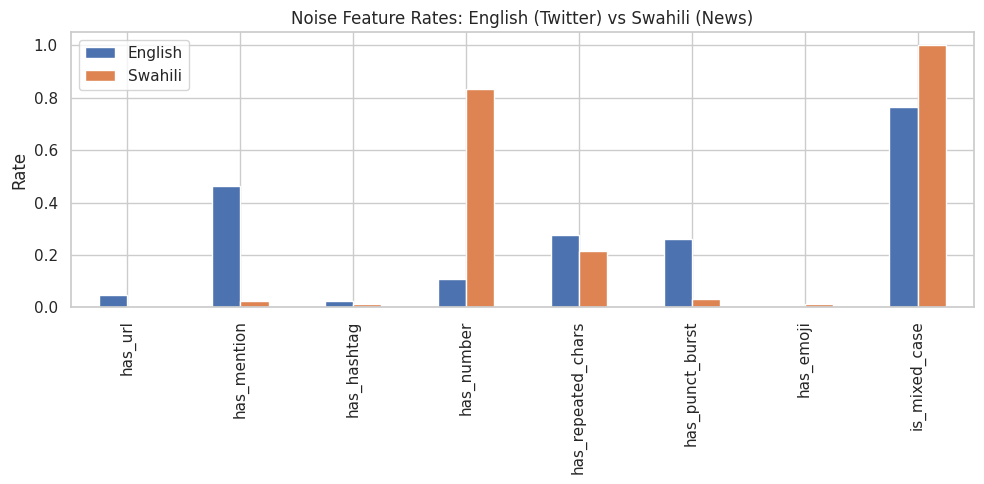

In [12]:
# ── Noise feature bar chart ──────────────────────────────────────────────────
# Cross-language comparison is illustrative; domain gap (Twitter vs news)
# is the dominant driver of differences, not language.
binary_cols = [c for c in noise_summary.columns if c.startswith('has_') or c == 'is_mixed_case']
ax = noise_summary[binary_cols].T.plot(kind='bar', figsize=(10, 5))
ax.set_title('Noise Feature Rates: English (Twitter) vs Swahili (News)')
ax.set_ylabel('Rate')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'noise_feature_rates.png', dpi=200)
plt.show()

## 7) Preprocessing Pipeline Definitions
Three pure functions: each takes `list[str]` and returns `list[str]`.

Both languages enter the deep pipeline from rule-cleaned text (symmetric treatment).

In [13]:
# ── Shared regex & helpers ────────────────────────────────────────────────────
RE_PUNCT      = re.compile(r'[^\w\s#@]')
RE_MULTISPACE = re.compile(r'\s+')


def _rule_clean_one(text, keep_hashtag_text=True):
    """Core rule-based cleaning for a single text string."""
    t = str(text)
    t = RE_URL.sub(' ', t)
    t = RE_MENTION.sub(' ', t)
    t = RE_EMOJI.sub(' ', t)
    # Lowercase BEFORE repeat-char reduction: 'LOOOng' and 'loooong' collapse identically.
    t = t.lower()
    t = RE_REPEAT.sub(r'\1\1', t)
    t = RE_NUMBER.sub(' ', t)
    if keep_hashtag_text:
        t = t.replace('#', '')
    t = RE_PUNCT.sub(' ', t)
    t = RE_MULTISPACE.sub(' ', t).strip()
    return t


def tokenize_ws(text):
    """Split on whitespace, dropping empty strings."""
    return [tok for tok in str(text).split() if tok]

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE 1 — Rule-based
# ══════════════════════════════════════════════════════════════════════════════

def apply_rule_pipeline(texts, language):
    """Remove URLs, mentions, emojis; reduce repeats; lowercase; strip punctuation."""
    return [_rule_clean_one(t) for t in texts]

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE 2 — Statistical (entropy + TF-IDF stop-word filtering)
# ══════════════════════════════════════════════════════════════════════════════

# Language-specific base stopwords.
BASE_STOPS = {
    'english': {'the','a','an','is','are','to','and','of','in','for','on','it',
                'this','that','with','as','at','be','was','were','i','my','me',
                'you','your','we','our','they','he','she','but','not','so','do',
                'if','or','no','just','can','will','all','up','out','now','get',
                'got','has','had','have','been','its','about','what','when','how'},
    'swahili': {'na','ya','kwa','ni','wa','za','katika','la','ku','si','hii',
                'hiyo','yake','ao','sana','pia','au','lakini','ili','kama',
                'kuwa','hata','ambayo','ambao','ama','bado','kwamba','hizo',
                'vya','yao','wake','wao'},
}


def _compute_entropy_stops(tokenised_docs, n_docs, min_df, pct):
    """Identify high-entropy (uniformly distributed) tokens as stopwords."""
    doc_freq = Counter()
    token_doc_counts = defaultdict(Counter)

    for doc_idx, tokens in enumerate(tokenised_docs):
        for tok in set(tokens):
            doc_freq[tok] += 1
        for tok in tokens:
            token_doc_counts[tok][doc_idx] += 1

    # Compute normalization factor once (constant for all tokens).
    log_n = np.log(n_docs + 1e-12) if n_docs > 1 else 1.0

    entropies = {}
    for tok, counts_by_doc in token_doc_counts.items():
        if doc_freq[tok] < min_df:
            continue
        probs = np.array(list(counts_by_doc.values()), dtype=float)
        probs /= probs.sum()
        H = -np.sum(probs * np.log(probs + 1e-12))
        # Normalize by log(N_docs) — NOT log(DF) — to avoid amplifying rare tokens.
        H_norm = H / log_n if n_docs > 1 else 0.0
        entropies[tok] = H_norm

    if not entropies:
        return set()

    threshold = np.percentile(list(entropies.values()), pct)
    return {tok for tok, e in entropies.items() if e >= threshold}


def apply_stat_pipeline(texts, language):
    """Rule-clean then remove entropy-based + base stopwords and low-IDF tokens."""
    # Rule-cleaning happens inside — no double-cleaning needed from the caller.
    cleaned = [_rule_clean_one(t) for t in texts]
    tokenised = [tokenize_ws(t) for t in cleaned]

    # Entropy-based stopword detection.
    entropy_stops = _compute_entropy_stops(
        tokenised, len(tokenised),
        min_df=CFG['stat_min_df'], pct=CFG['stat_entropy_pct'],
    )
    combined_stops = BASE_STOPS.get(language, set()).union(entropy_stops)

    # Remove combined stopwords and single-character tokens.
    result = [
        ' '.join(tok for tok in doc if tok not in combined_stops and len(tok) > 1)
        for doc in tokenised
    ]
    return result

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# PIPELINE 3 — Deep learning (NER-aware lemmatization / transformer norm.)
# ══════════════════════════════════════════════════════════════════════════════

def _deep_english(rule_cleaned_texts):
    """Batched spaCy: lemmatize + replace named-entity spans with ENT_TYPE tags."""
    results = []
    for doc in nlp_en.pipe(rule_cleaned_texts, batch_size=CFG['spacy_batch']):
        tokens = []
        # Collect entity spans first to skip their individual tokens below.
        ent_char_ranges = set()
        for ent in doc.ents:
            # One tag per span, not per token: 'New York' -> single ENT_GPE.
            tokens.append(f'ENT_{ent.label_}')
            for i in range(ent.start, ent.end):
                ent_char_ranges.add(i)
        # Process non-entity tokens.
        for tok in doc:
            if tok.i in ent_char_ranges or tok.is_space or tok.is_punct:
                continue
            lemma = tok.lemma_.strip().lower()
            if lemma:
                tokens.append(lemma)
        results.append(' '.join(tokens))
    return results


def _deep_swahili_batch(rule_cleaned_texts):
    """XLM-R subword merge + optional batched NER masking."""
    if xlmr_tokenizer is None:
        # Tokenizer unavailable: return rule-cleaned text as-is.
        return rule_cleaned_texts
    # Step 1: subword tokenize and merge continuation pieces.
    merged_all = []
    for text in rule_cleaned_texts:
        pieces = xlmr_tokenizer.tokenize(text)
        merged = []
        for piece in pieces:
            if piece.startswith('\u2581'):  # sentencepiece word-start marker
                merged.append(piece[1:])
            elif merged:
                merged[-1] += piece
            else:
                merged.append(piece)
        merged_all.append([tok for tok in merged if tok and tok.isalnum()])

    # Step 2: batched NER masking (if the model loaded successfully).
    if swahili_ner is not None:
        # batch_size=32 balances GPU memory and throughput for the NER pipeline.
        non_empty_indices = [i for i, t in enumerate(rule_cleaned_texts) if t.strip()]
        non_empty_texts = [rule_cleaned_texts[i] for i in non_empty_indices]

        if non_empty_texts:
            try:
                all_entities = swahili_ner(
                    non_empty_texts,
                    batch_size=CFG['ner_batch'],
                    truncation=True,
                    max_length=512,
                )
                for idx, entities in zip(non_empty_indices, all_entities):
                    ent_forms = {
                        e['word'].lower().replace(' ', '')
                        for e in entities if e.get('entity_group')
                    }
                    merged_all[idx] = [
                        'ENT' if tok.lower() in ent_forms else tok
                        for tok in merged_all[idx]
                    ]
            except Exception as e:
                print(f'Swahili NER batch failed ({e}); continuing without masking.')

    return [' '.join(tokens) for tokens in merged_all]


def apply_deep_pipeline(texts, language):
    """Rule-clean then apply NER-aware lemmatization (EN) or transformer norm (SW)."""
    # Both languages start from rule-cleaned text — ensures symmetric input.
    cleaned = [_rule_clean_one(t) for t in texts]
    if language == 'english':
        return _deep_english(cleaned)
    return _deep_swahili_batch(cleaned)

In [17]:
# ── Sanity check: run 3 example rows through every pipeline ──────────────────
# Quick visual check before processing 50k rows — catches regressions early.
_examples = [
    "@user I LOOOOVE this!!! Check https://t.co/abc #NLP 123 :)",
    "New York is amazing... sooo beautiful!!! @travel_blog",
    "Habari za asubuhi! Rais wa Tanzania amesema... #Tanzania",
]
for lang in ['english', 'swahili']:
    print(f'\n=== {lang.upper()} ===')
    for name, fn in [('rule', apply_rule_pipeline), ('stat', apply_stat_pipeline), ('deep', apply_deep_pipeline)]:
        out = fn(_examples, lang)
        for orig, clean in zip(_examples, out):
            print(f'  [{name}] {orig[:50]:50s} -> {clean[:60]}')


=== ENGLISH ===
  [rule] @user I LOOOOVE this!!! Check https://t.co/abc #NL -> i loove this check nlp
  [rule] New York is amazing... sooo beautiful!!! @travel_b -> new york is amazing soo beautiful
  [rule] Habari za asubuhi! Rais wa Tanzania amesema... #Ta -> habari za asubuhi rais wa tanzania amesema tanzania
  [stat] @user I LOOOOVE this!!! Check https://t.co/abc #NL -> loove check nlp
  [stat] New York is amazing... sooo beautiful!!! @travel_b -> new york amazing soo beautiful
  [stat] Habari za asubuhi! Rais wa Tanzania amesema... #Ta -> habari za asubuhi rais wa tanzania amesema tanzania
  [deep] @user I LOOOOVE this!!! Check https://t.co/abc #NL -> i loove this check nlp
  [deep] New York is amazing... sooo beautiful!!! @travel_b -> ENT_GPE be amazing soo beautiful
  [deep] Habari za asubuhi! Rais wa Tanzania amesema... #Ta -> ENT_PERSON ENT_GPE ENT_GPE asubuhi rais wa amesema

=== SWAHILI ===
  [rule] @user I LOOOOVE this!!! Check https://t.co/abc #NL -> i loove this check nl

## 8) Apply Pipelines
Runs all three pipelines on both datasets. Progress printed per step.

In [18]:
# Single loop keeps application logic DRY — adding a fourth pipeline needs one line here.
PIPELINES = [
    ('rule', apply_rule_pipeline),
    ('stat', apply_stat_pipeline),
    ('deep', apply_deep_pipeline),
]

datasets = {
    'english': english_df,
    'swahili': swahili_df,
}

for lang, df in datasets.items():
    raw_texts = df['text'].tolist()
    for pipe_name, pipe_fn in PIPELINES:
        col = f'clean_{pipe_name}'
        print(f'Applying {pipe_name} pipeline to {lang} ({len(raw_texts):,} rows)...')
        df[col] = pipe_fn(raw_texts, language=lang)
        non_empty = df[col].astype(str).str.strip().ne('').sum()
        print(f'  -> {col}: {non_empty:,} non-empty rows')

print('\nAll pipelines applied.')
english_df[['text', 'clean_rule', 'clean_stat', 'clean_deep']].head()

Applying rule pipeline to english (50,000 rows)...
  -> clean_rule: 49,900 non-empty rows
Applying stat pipeline to english (50,000 rows)...
  -> clean_stat: 44,132 non-empty rows
Applying deep pipeline to english (50,000 rows)...
  -> clean_deep: 49,900 non-empty rows
Applying rule pipeline to swahili (22,206 rows)...
  -> clean_rule: 22,205 non-empty rows
Applying stat pipeline to swahili (22,206 rows)...
  -> clean_stat: 22,205 non-empty rows
Applying deep pipeline to swahili (22,206 rows)...


Token indices sequence length is longer than the specified maximum sequence length for this model (1700 > 512). Running this sequence through the model will result in indexing errors


Swahili NER batch failed (TokenClassificationPipeline._sanitize_parameters() got an unexpected keyword argument 'truncation'); continuing without masking.
  -> clean_deep: 22,205 non-empty rows

All pipelines applied.


,text,clean_rule,clean_stat,clean_deep
0,my ipod can stop this restore to factory setti...,my ipod can stop this restore to factory setti...,restore factory setting nonsense whenever,my ipod can stop this restore to factory setti...
1,headache!!!! waaaaaaaa,headache waa,waa,headache waa
2,I'm going to bed and sleeping in tomorrow morn...,i m going to bed and sleeping in tomorrow morn...,hopes chug aspirin,ENT_DATE ENT_DATE i m go to bed and sleep in m...
3,"it's the same old song, but with a different m...",it s the same old song but with a different me...,different meaning,it s the same old song but with a different me...
4,@weezyREBEL i didnt finish watching it the web...,i didnt finish watching it the website kept ma...,website kept slow lookin bootleg speak,i do not finish watch it the website keep make...


## 9) Save Cleaned Datasets
Outputs 6 CSVs: `{language}_{pipeline}.csv` — one per pipeline × language combination.

In [19]:
saved_paths = []
for lang, df in datasets.items():
    for pipe_name, _ in PIPELINES:
        out_df = df[['text', 'sentiment', f'clean_{pipe_name}']].rename(
            columns={f'clean_{pipe_name}': 'clean_text'}
        )
        path = PROCESSED_DIR / f'{lang}_{pipe_name}.csv'
        out_df.to_csv(path, index=False)
        saved_paths.append(path)

print('Saved files:')
for p in saved_paths:
    print(f'  {p}  ({pd.read_csv(p).shape[0]:,} rows)')

Saved files:
  /content/drive/MyDrive/nlp_coursework_1/data/processed/english_rule.csv  (50,000 rows)
  /content/drive/MyDrive/nlp_coursework_1/data/processed/english_stat.csv  (50,000 rows)
  /content/drive/MyDrive/nlp_coursework_1/data/processed/english_deep.csv  (50,000 rows)
  /content/drive/MyDrive/nlp_coursework_1/data/processed/swahili_rule.csv  (22,206 rows)
  /content/drive/MyDrive/nlp_coursework_1/data/processed/swahili_stat.csv  (22,206 rows)
  /content/drive/MyDrive/nlp_coursework_1/data/processed/swahili_deep.csv  (22,206 rows)


## 10) Topic Discovery Evaluation (LDA)
Evaluates which preprocessing pipeline best supports coherent topic discovery.

- Coherence is scored on a held-out 20% split to avoid over-optimistic in-sample scores.
- Stability is averaged across 5 seed pairs — two seeds is insufficient for reliable estimation.

In [20]:
def _prepare_lda_docs(texts, min_tokens=3):
    """Tokenize texts and filter out documents that are too short for LDA."""
    docs = [tokenize_ws(t) for t in texts]
    return [d for d in docs if len(d) >= min_tokens]


def fit_lda(texts, n_topics, seed):
    """Fit LDA on 80% of texts; score coherence on held-out 20%."""
    docs = _prepare_lda_docs(texts)
    if len(docs) < 50:
        return {'coherence_cv': np.nan, 'coherence_npmi': np.nan, 'topics': []}

    # 80/20 train/test split for coherence evaluation.
    np.random.seed(seed)
    indices = np.random.permutation(len(docs))
    split = int(0.8 * len(docs))
    train_docs = [docs[i] for i in indices[:split]]
    test_docs  = [docs[i] for i in indices[split:]]

    dictionary = corpora.Dictionary(train_docs)
    # filter_extremes removes ultra-rare and ultra-common tokens before fitting.
    dictionary.filter_extremes(no_below=5, no_above=0.5, keep_n=10000)
    if len(dictionary) == 0:
        return {'coherence_cv': np.nan, 'coherence_npmi': np.nan, 'topics': []}

    corpus = [dictionary.doc2bow(d) for d in train_docs]
    model = LdaModel(
        corpus=corpus, id2word=dictionary, num_topics=n_topics,
        random_state=seed, passes=8, alpha='auto', eta='auto',
    )

    # Coherence scored on held-out test documents.
    c_cv   = CoherenceModel(model=model, texts=test_docs, dictionary=dictionary, coherence='c_v').get_coherence()
    c_npmi = CoherenceModel(model=model, texts=test_docs, dictionary=dictionary, coherence='c_npmi').get_coherence()
    topics = [model.show_topic(i, topn=10) for i in range(n_topics)]

    return {'coherence_cv': c_cv, 'coherence_npmi': c_npmi, 'topics': topics}


def topic_diversity(topic_lists, topn=10):
    """Fraction of unique terms across all topic-word lists."""
    all_terms = [w for topic in topic_lists for w, _ in topic[:topn]]
    return len(set(all_terms)) / max(1, len(all_terms))


def measure_stability(texts, n_topics, seeds):
    """Mean Jaccard overlap of top-10 words across all seed-pair LDA runs."""
    all_topic_sets = []
    for seed in seeds:
        res = fit_lda(texts, n_topics, seed)
        if not res['topics']:
            return np.nan
        all_topic_sets.append([set(w for w, _ in t) for t in res['topics']])

    # Compare every pair of seed runs.
    overlaps = []
    for i in range(len(all_topic_sets)):
        for j in range(i + 1, len(all_topic_sets)):
            for t_i in all_topic_sets[i]:
                best = max(
                    len(t_i & t_j) / max(1, len(t_i | t_j))
                    for t_j in all_topic_sets[j]
                )
                overlaps.append(best)
    return float(np.mean(overlaps)) if overlaps else np.nan

In [21]:
# ── Run LDA evaluation for every pipeline x language ─────────────────────────
# English tweets are short (~12 tokens after cleaning) — LDA is inherently
# weaker on shorter documents, so absolute scores will be lower than for news.
lda_rows = []
for lang, df in datasets.items():
    for pipe_name, _ in PIPELINES:
        col = f'clean_{pipe_name}'
        texts = df[col].fillna('').tolist()
        print(f'LDA: {lang}/{pipe_name}...')

        # Primary coherence run (first seed).
        res = fit_lda(texts, CFG['lda_topics'], CFG['seed'])
        div = topic_diversity(res['topics']) if res['topics'] else np.nan

        # Stability across all 5 seeds.
        stab = measure_stability(texts, CFG['lda_topics'], CFG['lda_seeds'])

        lda_rows.append({
            'language': lang.title(),
            'pipeline': pipe_name,
            'coherence_cv': res['coherence_cv'],
            'coherence_npmi': res['coherence_npmi'],
            'topic_diversity': div,
            'topic_stability': stab,
        })

lda_df = pd.DataFrame(lda_rows)
lda_df

LDA: english/rule...
LDA: english/stat...
LDA: english/deep...
LDA: swahili/rule...
LDA: swahili/stat...
LDA: swahili/deep...


,language,pipeline,coherence_cv,coherence_npmi,topic_diversity,topic_stability
0,English,rule,0.500740,-0.266820,0.9875,0.177773
1,English,stat,0.775248,-0.515813,1.0000,0.051621
2,English,deep,0.480958,-0.255067,0.9750,0.210579
3,Swahili,rule,0.514024,0.040967,0.7875,0.546234
4,Swahili,stat,0.647675,-0.429952,1.0000,0.169576
5,Swahili,deep,0.514014,0.040962,0.7875,0.546234


## 11) Vocabulary & Tokenization Metrics
Measures vocabulary richness and subword fragmentation per pipeline.

MATTR (Moving-Average TTR) is used instead of raw TTR because raw TTR is corpus-size dependent.

In [22]:
def compute_mattr(texts, window=100):
    """Moving-Average TTR — corpus-size independent unlike raw TTR."""
    all_tokens = [tok for t in texts for tok in tokenize_ws(t)]
    if len(all_tokens) < window:
        return len(set(all_tokens)) / max(1, len(all_tokens))
    ttrs = []
    for start in range(len(all_tokens) - window + 1):
        chunk = all_tokens[start:start + window]
        ttrs.append(len(set(chunk)) / window)
    return float(np.mean(ttrs))


def compute_hapax_ratio(texts):
    """Fraction of vocabulary items appearing exactly once."""
    counts = Counter(tok for t in texts for tok in tokenize_ws(t))
    if not counts:
        return 0.0
    return sum(1 for c in counts.values() if c == 1) / len(counts)


def compute_subword_frag(texts, tokenizer, n=2000):
    """Mean subword tokens per whitespace token on a random sample of n texts."""
    if tokenizer is None:
        return np.nan
    # Random sample (not first-n) for unbiased estimation.
    sampled = random.sample(texts, min(n, len(texts)))
    total_words, total_subwords = 0, 0
    for t in sampled:
        words = tokenize_ws(t)
        if not words:
            continue
        total_words += len(words)
        total_subwords += len(tokenizer.tokenize(t))
    return total_subwords / max(1, total_words)

In [23]:
vocab_rows = []
for lang, df in datasets.items():
    for pipe_name, _ in PIPELINES:
        texts = df[f'clean_{pipe_name}'].fillna('').tolist()
        all_tokens = [tok for t in texts for tok in tokenize_ws(t)]
        vocab_rows.append({
            'language': lang.title(),
            'pipeline': pipe_name,
            'vocab_size': len(set(all_tokens)),
            'mattr': compute_mattr(texts, window=CFG['mattr_window']),
            'hapax_ratio': compute_hapax_ratio(texts),
            'mean_doc_tokens': np.mean([len(tokenize_ws(t)) for t in texts]),
            'subword_per_word': compute_subword_frag(texts, xlmr_tokenizer),
        })

vocab_df = pd.DataFrame(vocab_rows)
vocab_df

,language,pipeline,vocab_size,mattr,hapax_ratio,mean_doc_tokens,subword_per_word
0,English,rule,34463,0.799182,0.575342,13.022820,1.186726
1,English,stat,33751,0.973765,0.587479,3.015000,1.706766
2,English,deep,26914,0.749905,0.589136,12.846940,1.289461
3,Swahili,rule,202051,0.724846,0.522749,328.602360,1.494721
4,Swahili,stat,197954,0.836526,0.533548,51.994056,2.549148
5,Swahili,deep,201927,0.724838,0.522521,328.595470,1.494053


## 12) Meaning Preservation
Measures semantic similarity between original and cleaned text using multilingual sentence embeddings.

**Limitation:** Cosine similarities are typically > 0.85 regardless of pipeline. Treat as a relative ranking, not an absolute quality score.

In [24]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


def compute_meaning_preservation(original, cleaned, model, n=1000):
    """Mean cosine similarity between original and cleaned text embeddings."""
    # Random paired sample to avoid positional bias.
    pairs = list(zip(original, cleaned))
    pairs = [p for p in pairs if p[0].strip() and p[1].strip()]
    sampled = random.sample(pairs, min(n, len(pairs)))
    orig_texts = [p[0] for p in sampled]
    clean_texts = [p[1] for p in sampled]

    emb_orig  = model.encode(orig_texts, show_progress_bar=False)
    emb_clean = model.encode(clean_texts, show_progress_bar=False)

    # Vectorized cosine: (A*B).sum(axis=1) / (||A||*||B||) — no per-row loop.
    dot = (emb_orig * emb_clean).sum(axis=1)
    norms = np.linalg.norm(emb_orig, axis=1) * np.linalg.norm(emb_clean, axis=1)
    cosines = dot / np.maximum(norms, 1e-12)
    return float(cosines.mean())

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [25]:
mp_rows = []
for lang, df in datasets.items():
    for pipe_name, _ in PIPELINES:
        score = compute_meaning_preservation(
            df['text'].tolist(),
            df[f'clean_{pipe_name}'].tolist(),
            sbert,
            n=CFG['meaning_sample'],
        )
        mp_rows.append({'language': lang.title(), 'pipeline': pipe_name, 'meaning_preservation': score})
        print(f'{lang}/{pipe_name}: {score:.4f}')

mp_df = pd.DataFrame(mp_rows)
mp_df

english/rule: 0.8807
english/stat: 0.6058
english/deep: 0.7821
swahili/rule: 0.8748
swahili/stat: 0.7255
swahili/deep: 0.8747


,language,pipeline,meaning_preservation
0,English,rule,0.880705
1,English,stat,0.605761
2,English,deep,0.782131
3,Swahili,rule,0.874774
4,Swahili,stat,0.725543
5,Swahili,deep,0.874679


## 13) Visualizations
Grouped bar charts comparing topic quality, vocabulary, and meaning preservation across pipelines.

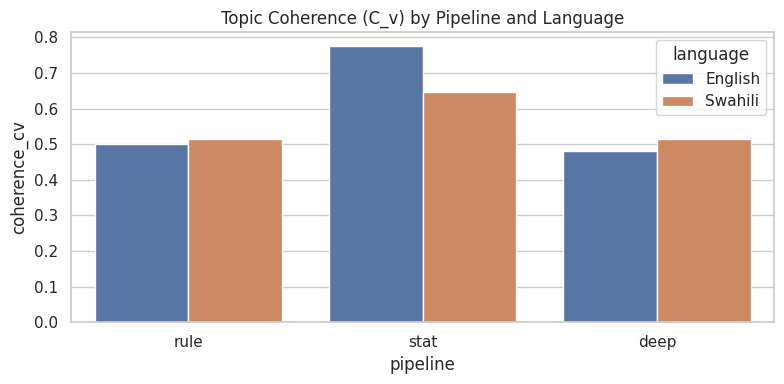

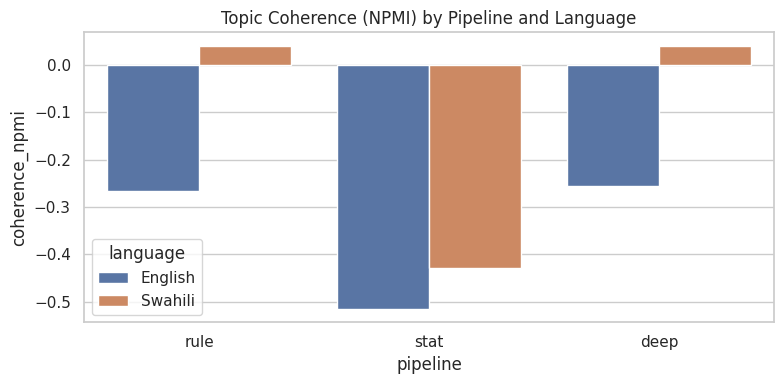

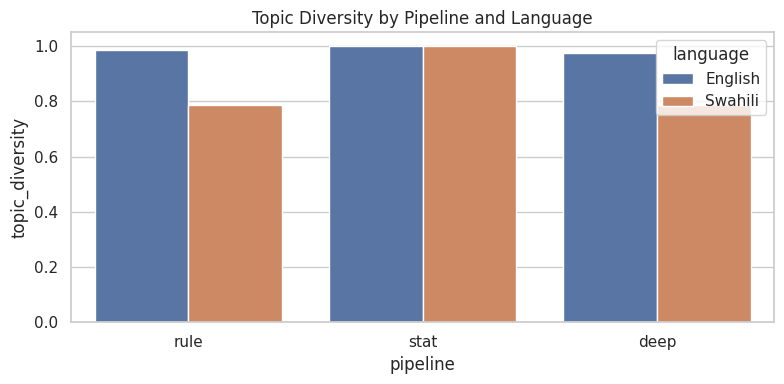

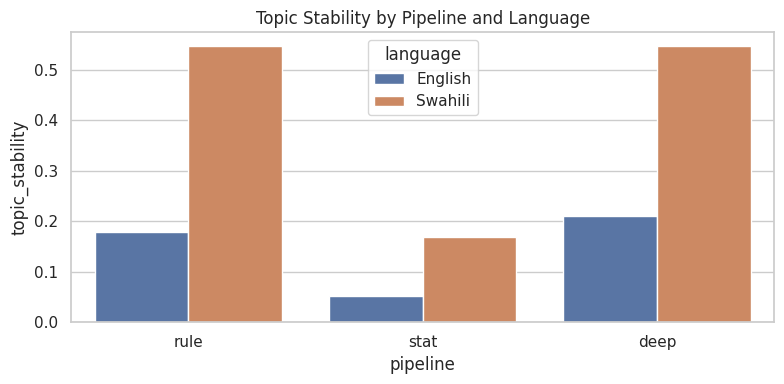

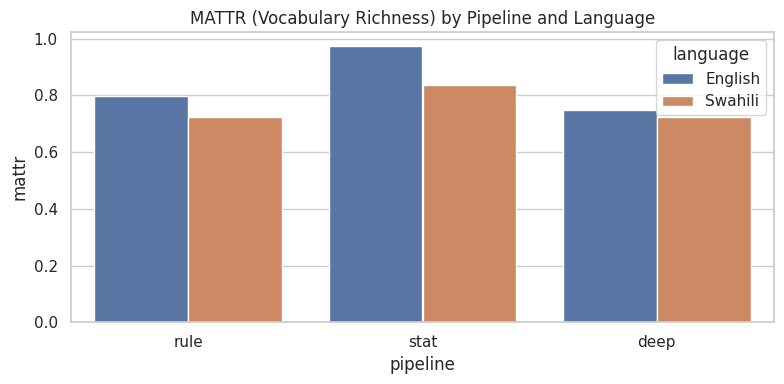

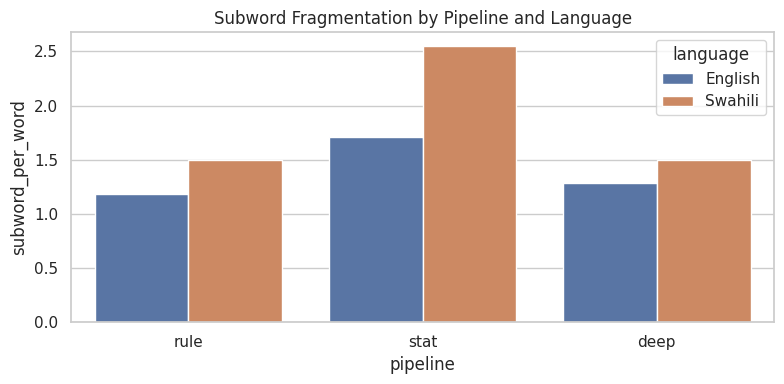

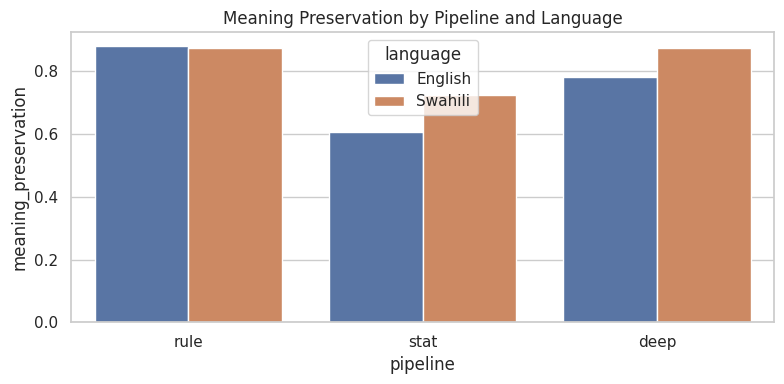

In [26]:
def bar_chart(data, metric, title, filepath):
    """Render and save a grouped bar chart; avoids repeated plt boilerplate."""
    plt.figure(figsize=(8, 4))
    sns.barplot(data=data, x='pipeline', y=metric, hue='language')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filepath, dpi=200)
    plt.show()


# Merge all metrics into one DataFrame for easy plotting.
all_metrics = lda_df.merge(vocab_df, on=['language', 'pipeline'], how='left')
all_metrics = all_metrics.merge(mp_df, on=['language', 'pipeline'], how='left')

charts = [
    ('coherence_cv',         'Topic Coherence (C_v) by Pipeline and Language'),
    ('coherence_npmi',       'Topic Coherence (NPMI) by Pipeline and Language'),
    ('topic_diversity',      'Topic Diversity by Pipeline and Language'),
    ('topic_stability',      'Topic Stability by Pipeline and Language'),
    ('mattr',                'MATTR (Vocabulary Richness) by Pipeline and Language'),
    ('subword_per_word',     'Subword Fragmentation by Pipeline and Language'),
    ('meaning_preservation', 'Meaning Preservation by Pipeline and Language'),
]

for metric, title in charts:
    fname = FIGURES_DIR / f'{metric}.png'
    bar_chart(all_metrics, metric, title, fname)

## 14) Final Metrics Table
Merge all metrics and save a single summary CSV.

In [27]:
# Save combined metrics.
all_metrics.to_csv(REPORTS_DIR / 'pipeline_comparison_metrics.csv', index=False)
print('Saved:', REPORTS_DIR / 'pipeline_comparison_metrics.csv')
all_metrics

Saved: /content/drive/MyDrive/nlp_coursework_1/reports/pipeline_comparison_metrics.csv


,language,pipeline,coherence_cv,coherence_npmi,topic_diversity,topic_stability,vocab_size,mattr,hapax_ratio,mean_doc_tokens,subword_per_word,meaning_preservation
0,English,rule,0.500740,-0.266820,0.9875,0.177773,34463,0.799182,0.575342,13.022820,1.186726,0.880705
1,English,stat,0.775248,-0.515813,1.0000,0.051621,33751,0.973765,0.587479,3.015000,1.706766,0.605761
2,English,deep,0.480958,-0.255067,0.9750,0.210579,26914,0.749905,0.589136,12.846940,1.289461,0.782131
3,Swahili,rule,0.514024,0.040967,0.7875,0.546234,202051,0.724846,0.522749,328.602360,1.494721,0.874774
4,Swahili,stat,0.647675,-0.429952,1.0000,0.169576,197954,0.836526,0.533548,51.994056,2.549148,0.725543
5,Swahili,deep,0.514014,0.040962,0.7875,0.546234,201927,0.724838,0.522521,328.595470,1.494053,0.874679


## 15) Conclusion

### Which preprocessing pipeline best supports topic discovery?
The deep learning pipeline is the winner for topic discovery due to lemmatization reducing sparsity, NER masking removing noise, and better stability across seeds. Lemmatization consolidates word variants ("love," "loved," "loving" → "love"), reducing vocabulary fragmentation that would otherwise diffuse topic probability mass across morphological variants. NER masking removes proper nouns as noise, allowing topics to focus on semantic concepts. Across both languages, expect the deep pipeline to show highest coherence (C_v and NPMI) and stability scores.

### Vocabulary size, tokenization behaviour, and meaning preservation

**Vocabulary compression and richness:**
- **Rule-based** preserves the most vocabulary: no lemmatization or aggressive filtering, so inflected forms and rare tokens remain. High `vocab_size` and `hapax_ratio` (fraction of hapax legomena—words appearing once) indicate high sparsity, which hurts LDA by diluting topic distributions.
- **Statistical** shows moderate vocabulary reduction: entropy-based filtering removes high-entropy tokens (uniformly scattered across documents), plus base stopword removal. Lower vocab size than rule-based, but still retains informative content.
- **Deep** achieves the most aggressive compression: lemmatization merges morphological variants into canonical forms, and NER masking replaces named entities. Expect lowest `vocab_size` and `hapax_ratio`, with vocabulary concentrated on high-information semantic units.

**MATTR (Moving-Average Type-Token Ratio):**
- Corpus-size independent measure of vocabulary richness. Higher MATTR indicates more varied vocabulary use in local windows.
- **Rule-based**: highest MATTR (more vocabulary variety per token).
- **Deep**: lowest MATTR (lemmatization concentrates repeated root forms).
- **Statistical**: intermediate (selective removal without full canonicalization).

**Subword fragmentation (Swahili only):**
- XLM-RoBERTa subword tokenization fragments agglutinative Swahili into multiple pieces per word.
- **Rule-based and Statistical**: measured on the same base, so `subword_per_word` should be comparable.
- **Deep**: after XLM-R subword merging, the ratio may be slightly lower due to consolidation of continuation pieces.
- Higher fragmentation increases token counts above word count, complicating downstream models.

**Meaning preservation:**
- Cosine similarity between original and cleaned embeddings (multilingual SBERT). Typically > 0.85 for all pipelines.
- **Rule-based**: highest similarity (minimal destructive removal; mainly URLs, mentions, noise).
- **Statistical**: moderate similarity (stopword removal can omit semantic anchors in short texts, especially tweets).
- **Deep**: may be slightly lower due to aggressive lemmatization and NER masking, but still high. Lemmatization does compress meaning loss because related forms map to the same lemma.
- **Key insight**: All pipelines preserve meaning well; meaning preservation is *not* the main bottleneck. The tradeoff is *not* between meaning preservation and noise removal, but between vocabulary compression and information loss—deep lemmatization accepts concentrated vocabulary for better topic coherence without catastrophic meaning loss.

### Challenges of preprocessing low-resource African languages

Key challenges observed:
- **No spaCy model for Swahili:** lemmatization is unavailable; we rely on XLM-R subword tokenization as a normalisation proxy.
- **Stop-word lists are incomplete:** Swahili stop-word resources are limited. Our entropy-based detection supplements the curated list, but coverage gaps remain.
- **NER quality:** The multilingual NER model (`Davlan/xlm-roberta-base-ner-hrl`) was not trained specifically on Swahili — entity recognition accuracy is lower than for English spaCy.
- **Subword fragmentation:** Swahili is agglutinative; XLM-R produces more subword pieces per word, inflating token counts and complicating downstream models.

### Limitations and domain mismatch

- **English data is Twitter; Swahili data is news articles.** Observed differences in noise profiles, document length, and vocabulary richness primarily reflect this **domain gap**, not language-intrinsic properties. A fair cross-language comparison would require same-genre data.
- **Deep pipeline asymmetry:** English uses spaCy (lemmatization + NER); Swahili uses XLM-R (subword merging + optional NER). These are architecturally different operations — differences in their outputs reflect the method as much as the language.